# POWGEN data reduction

## Introduction

This notebook gives a concise overview of how to use the ESSDiffraction package with Sciline.
It uses a simple reduction workflow for the SNS [POWGEN](https://sns.gov/powgen) experiment.

We begin with relevant imports.
We will be using tutorial data downloaded with `pooch`.
If you get an error about a missing module `pooch`, you can install it with `!pip install pooch`:

In [1]:
import scipp as sc
import scippneutron as scn
import scippneutron.io

from ess import powder
from ess.snspowder import powgen
import ess.snspowder.powgen.data  # noqa: F401
from ess.powder.types import *

## Create and configure the workflow

We begin by creating the Powgen workflow object which is a skeleton for reducing Powgen data, with pre-configured steps.

In [2]:
workflow = powgen.PowgenWorkflow()

We then need to set the missing parameters which are specific to each experiment
(the keys are types defined in [essdiffraction.powder.types](../../generated/modules/ess.powder.types.rst)):

In [3]:
workflow[Filename[SampleRun]] = powgen.data.powgen_tutorial_sample_file()
workflow[Filename[VanadiumRun]] = powgen.data.powgen_tutorial_vanadium_file()
workflow[CalibrationFilename] = powgen.data.powgen_tutorial_calibration_file()
# The upper bounds mode is not yet implemented.
workflow[UncertaintyBroadcastMode] = UncertaintyBroadcastMode.drop
# Edges for binning in d-spacing
workflow[DspacingBins] = sc.linspace("dspacing", 0.0, 2.3434, 201, unit="angstrom")
# Mask in time-of-flight to crop to valid range
workflow[TofMask] = lambda x: (x < sc.scalar(0.0, unit="us")) | (
    x > sc.scalar(16666.67, unit="us")
)
workflow[TwoThetaMask] = None
workflow[WavelengthMask] = None
# No pixel masks
workflow = powder.with_pixel_mask_filenames(workflow, [])

## Use the workflow

### Compute final result

We can get the graph for computing the final intensity as a function of d-spacing:

In [4]:
IntensityDspacing[SampleRun] in workflow.get(IntensityDspacing[SampleRun]).keys()

True

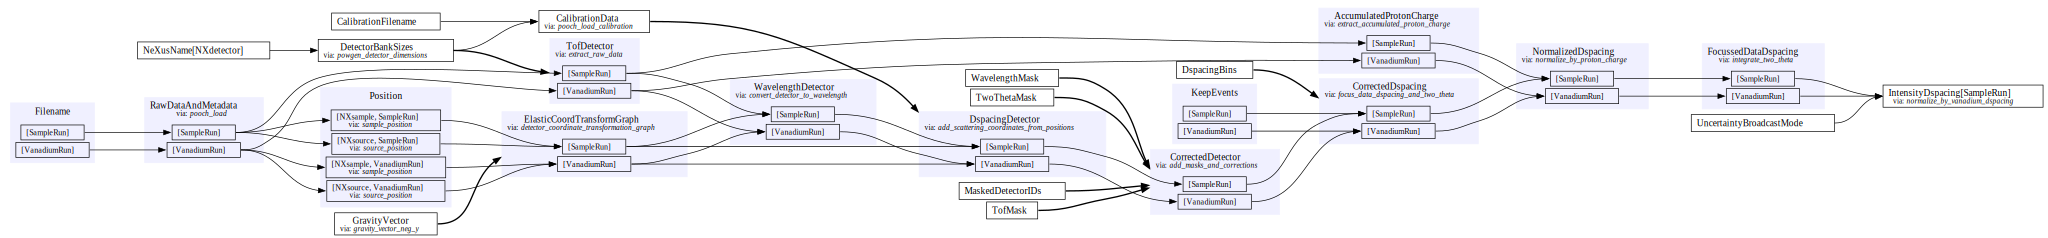

In [5]:
workflow.visualize(IntensityDspacing[SampleRun], graph_attr={"rankdir": "LR"})

Now we compute the result:

In [6]:
result = workflow.compute(IntensityDspacing[SampleRun])
result

<scipp.DataArray>
Dimensions: Sizes[dspacing:200, ]
Coordinates:
* dspacing                  float64             [Å]  (dspacing [bin-edge])  [0, 0.011717, ..., 2.33168, 2.3434]
  sample_position           vector3              [m]  ()  (0, 0, 0)
  source_position           vector3              [m]  ()  (0, 0, -60)
Data:
                          DataArrayView        <no unit>  (dspacing)  binned data: dim='event', content=DataArray(
          dims=(event: 17926980),
          data=float64[dimensionless],
          coords={'tof':float64[µs], 'wavelength':float64[Å], 'dspacing':float64[Å]},
          masks={'tof':bool})

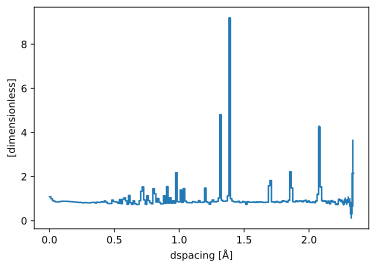

In [7]:
dspacing_histogram = result.hist()
dspacing_histogram.plot()

### Save reduced data to file

We ultimately need to write the reduced data to a file.
This could be done with the `result` we computed above.
But we can use the workflow to provide additional parameters (in this case only the file name) as shown below.
See also the [File output](https://scipp.github.io/sciline/recipes/side-effects-and-file-writing.html#File-output) docs of Sciline.

For simplicity we write a simply xye file with 3 columns: $d$-spacing, intensity, standard deviation of intensity.

In [8]:
def save_xye(
    reduced_data: IntensityDspacing[SampleRun],
    out_filename: OutFilename,
) -> None:
    data = reduced_data.hist()
    data.coords["dspacing"] = sc.midpoints(data.coords["dspacing"])
    scn.io.save_xye(out_filename, data, coord="dspacing")

Insert a new parameter to set the file name.
This could have been done at the top where the other parameters are defined.

In [9]:
workflow[OutFilename] = "reduced.xye"

And use the workflow to write the file.
Note that this recomputes the result!

In [10]:
workflow.bind_and_call(save_xye)

### Compute intermediate results

For inspection and debugging purposes, we can also compute intermediate results.
To avoid repeated computation (including costly loading of files), we can request multiple results at once, including the final result, if desired.
For example:

In [11]:
results = workflow.compute(
    (
        WavelengthDetector[SampleRun],
        CorrectedDetector[SampleRun],
    )
)

In [12]:
results[WavelengthDetector[SampleRun]]

<scipp.DataArray>
Dimensions: Sizes[bank:23, column:154, row:7, ]
Coordinates:
  gd_prtn_chrg              float64           [µAh]  ()  1171.95
  position                  vector3              [m]  (bank, column, row)  [(1.17451, -1.01106, -2.03797), (1.18148, -0.959466, -2.05334), ..., (1.81429, 0.0956584, 3.84338), (1.81375, 0.149937, 3.8427)]
  sample_position           vector3              [m]  ()  (0, 0, 0)
  source_position           vector3              [m]  ()  (0, 0, -60)
* spectrum                    int32        <no unit>  (bank, column, row)  [1, 2, ..., 24793, 24794]
Data:
                          DataArrayView        <no unit>  (bank, column, row)  binned data: dim='event', content=DataArray(
          dims=(event: 17926980),
          data=float32[counts],
          coords={'tof':float64[µs], 'wavelength':float64[Å]})

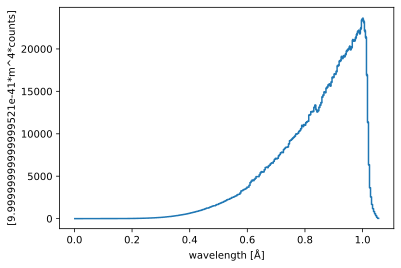

In [13]:
results[CorrectedDetector[SampleRun]].bins.concat().hist(wavelength=300).plot()

## Group by scattering angle

The above workflow focuses the data by merging all instrument pixels to produce a 1d d-spacing curve.
If instead we want to group into $2\theta$ bins, we can alter the workflow parameters by adding some binning in $2\theta$:

In [14]:
workflow[TwoThetaBins] = sc.linspace(
    dim="two_theta", unit="deg", start=25.0, stop=90.0, num=17
).to(unit="rad")

We then have to request a final result that depends on both d-spacing and $2\theta$:

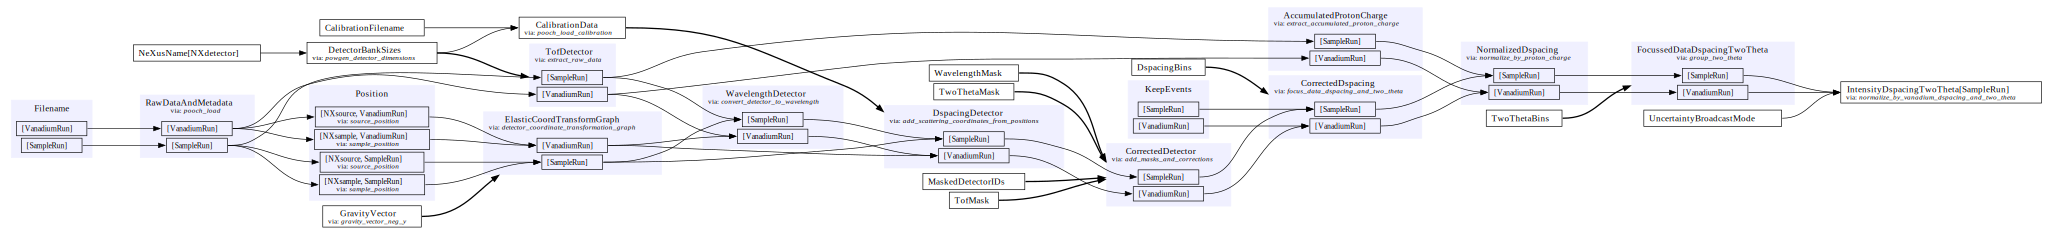

In [15]:
workflow.visualize(IntensityDspacingTwoTheta[SampleRun], graph_attr={"rankdir": "LR"})

Compute and plot the result:

In [16]:
grouped_dspacing = workflow.compute(IntensityDspacingTwoTheta[SampleRun])
grouped_dspacing

<scipp.DataArray>
Dimensions: Sizes[two_theta:16, dspacing:200, ]
Coordinates:
* dspacing                  float64             [Å]  (dspacing [bin-edge])  [0, 0.011717, ..., 2.33168, 2.3434]
  sample_position           vector3              [m]  ()  (0, 0, 0)
  source_position           vector3              [m]  ()  (0, 0, -60)
* two_theta                 float64            [rad]  (two_theta [bin-edge])  [0.436332, 0.507236, ..., 1.49989, 1.5708]
Data:
                          DataArrayView        <no unit>  (two_theta, dspacing)  binned data: dim='event', content=DataArray(
          dims=(event: 7090240),
          data=float64[dimensionless],
          coords={'tof':float64[µs], 'wavelength':float64[Å], 'dspacing':float64[Å]},
          masks={'tof':bool})
Masks:
  zero_vanadium                bool        <no unit>  (two_theta, dspacing)  [False, False, ..., True, True]

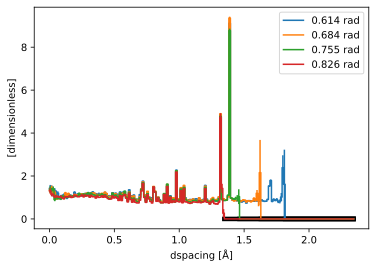

In [17]:
angle = sc.midpoints(grouped_dspacing.coords["two_theta"])
sc.plot(
    {
        f"{angle[group].value:.3f} {angle[group].unit}": grouped_dspacing[
            "two_theta", group
        ].hist()
        for group in range(2, 6)
    }
)

Or we can view it as a 2D plot, which should display powder peaks as vertical bright lines:

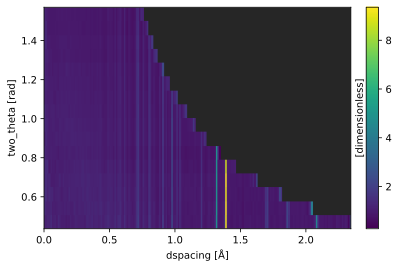

In [18]:
grouped_dspacing.hist().plot()